# 05 · Gene Set Enrichment Analysis (GSEA)
**Input:** `data/processed/dea_results.csv`  
**Output:** `results/figures/gsea_*.png`, `results/tables/gsea_*.csv`

Runs ranked GSEA across GO Biological Process, GO Molecular Function,
GO Cellular Component, and KEGG pathways using `clusterProfiler` in R.
Highlights key HCC-relevant themes: lipid metabolism, glycolysis, PI3K-AKT,
and immune regulation.

**Requires:** R packages — `clusterProfiler`, `org.Hs.eg.db`, `enrichplot`  
Install with: `Rscript env/r_packages.R`


In [1]:
import sys
from pathlib import Path

def _find_repo_root(start):
    for p in [start, *start.parents]:
        if (p / "paths.py").exists():
            return p
    raise FileNotFoundError("paths.py not found — run: python scripts/data_download.py")

REPO_ROOT = _find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from paths import REPO_ROOT, RAW_DIR, PROC_DIR, FIGURES_DIR, TABLES_DIR, REPORTS_DIR, MODELS_DIR
print(f"Repo root : {REPO_ROOT}")


Repo root : C:\Users\shoko\OneDrive\Desktop\project\HCC_DD


In [2]:
import os

# ── R environment (update R_HOME if needed) ───────────────────────────────────
# macOS  : /Library/Frameworks/R.framework/Resources
# Linux  : /usr/lib/R  (or check: which R)
# Windows: r"C:\Program Files\R\R-4.5.3"
R_HOME =  r"C:\Program Files\R\R-4.5.3"#os.environ.get("R_HOME", "")
if R_HOME:
    os.environ["R_HOME"] = R_HOME
    if sys.platform == "win32":
        os.environ["PATH"] = os.path.join(R_HOME,"bin","x64") + ";" + os.environ["PATH"]

%load_ext rpy2.ipython
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import default_converter
import anndata2ri
print("R environment ready")


R environment ready


In [3]:
%%R
# Install GSEA R packages if missing (safe to re-run)
gsea_pkgs <- c("clusterProfiler","org.Hs.eg.db","enrichplot","DOSE","ggplot2","ReactomePA")
if (!requireNamespace("BiocManager", quietly=TRUE))
    install.packages("BiocManager", repos="https://cloud.r-project.org")
for (pkg in gsea_pkgs) {
    if (!requireNamespace(pkg, quietly=TRUE))
        BiocManager::install(pkg, ask=FALSE, update=FALSE)
}
suppressPackageStartupMessages({
    library(clusterProfiler); library(org.Hs.eg.db)
    library(enrichplot);      library(DOSE); library(ggplot2)
})
cat("GSEA packages loaded\n")


GSEA packages loaded




In addition: Warning message:

   File C:\Users\shoko\OneDrive\Documents/.Renviron contains invalid line(s)
tools40"
   They were ignored
 


## Prepare ranked gene list

In [4]:
import pandas as pd, numpy as np

dea = pd.read_csv(PROC_DIR / "dea_results.csv")
print(f"DEGs loaded: {len(dea)}")

# Rank by log2FC — GSEA uses the full ranked list, not just significant genes
ranked = (dea[["gene","log2FC"]].dropna()
           .groupby("gene", as_index=False).mean()
           .sort_values("log2FC", ascending=False))
ranked.to_csv(PROC_DIR / "ranked_genes_log2fc.tsv", sep="\t", index=False, header=False)
print(f"Ranked list: {len(ranked)} genes")
print(ranked.head(10))


DEGs loaded: 1385
Ranked list: 1385 genes
         gene     log2FC
1361     XIST  31.180847
880     OLFM4  28.968952
29      ADH1C  28.503433
1235     TFF2  28.247526
265   CEACAM6  28.181560
777       MIA  28.101700
1162   SMIM22  27.783546
101      AQP5  27.590366
508     GABRP  27.233480
337      CTSE   9.171602


## Run GSEA (GO-BP, GO-MF, GO-CC, KEGG)

In [ ]:
PROC_DIR = str(PROC_DIR)

In [ ]:
%%R -i PROC_DIR
# PROC_DIR <- "../data/processed"  
file_path <- file.path(PROC_DIR, "ranked_genes_log2fc.tsv")
rnk <- read.table(file_path, sep="\t", header=FALSE)
colnames(rnk) <- c("SYMBOL","log2FC")
rnk <- rnk[order(rnk$log2FC, decreasing=TRUE), ]


In [7]:
%%R -i PROC_DIR

# Map gene symbols to Entrez IDs (required by clusterProfiler)
mapping  <- bitr(rnk$SYMBOL, fromType="SYMBOL", toType="ENTREZID", OrgDb=org.Hs.eg.db)
rnk2     <- merge(rnk, mapping, by="SYMBOL")
rnk2     <- rnk2[order(rnk2$log2FC, decreasing=TRUE), ]
geneList <- rnk2$log2FC
names(geneList) <- rnk2$ENTREZID

set.seed(42)
GSEA_PARAMS <- list(minGSSize=15, maxGSSize=500, pvalueCutoff=0.05, verbose=FALSE)

cat("Running GO Biological Process...\n")
gsea_bp <- do.call(gseGO, c(list(geneList=geneList,OrgDb=org.Hs.eg.db,
                                  ont="BP",keyType="ENTREZID"), GSEA_PARAMS))
cat("Running GO Molecular Function...\n")
gsea_mf <- do.call(gseGO, c(list(geneList=geneList,OrgDb=org.Hs.eg.db,
                                  ont="MF",keyType="ENTREZID"), GSEA_PARAMS))
cat("Running GO Cellular Component...\n")
gsea_cc <- do.call(gseGO, c(list(geneList=geneList,OrgDb=org.Hs.eg.db,
                                  ont="CC",keyType="ENTREZID"), GSEA_PARAMS))
cat("Running KEGG...\n")
gsea_kegg <- do.call(gseKEGG, c(list(geneList=geneList,organism="hsa"), GSEA_PARAMS))

cat(sprintf("\nGO-BP terms : %d\n", nrow(as.data.frame(gsea_bp))))
cat(sprintf("GO-MF terms : %d\n", nrow(as.data.frame(gsea_mf))))
cat(sprintf("GO-CC terms : %d\n", nrow(as.data.frame(gsea_cc))))
cat(sprintf("KEGG paths  : %d\n", nrow(as.data.frame(gsea_kegg))))


Running GO Biological Process...
Running GO Molecular Function...
Running GO Cellular Component...
Running KEGG...

GO-BP terms : 120
GO-MF terms : 10
GO-CC terms : 16
KEGG paths  : 2


'select()' returned 1:1 mapping between keys and columns
Reading KEGG annotation online: "https://rest.kegg.jp/link/hsa/pathway"...
Reading KEGG annotation online: "https://rest.kegg.jp/list/pathway/hsa"...
In addition: Warning messages:
1: In bitr(rnk$SYMBOL, fromType = "SYMBOL", toType = "ENTREZID", OrgDb = org.Hs.eg.db) :
  5.13% of input gene IDs are fail to map...
2: In fgseaMultilevel(pathways = pathways, stats = stats, minSize = minSize,  :
  For some of the pathways the P-values were likely overestimated. For such pathways log2err is set to NA.
3: In fgseaMultilevel(pathways = pathways, stats = stats, minSize = minSize,  :
  There were 2 pathways for which P-values were not calculated properly due to unbalanced (positive and negative) gene-level statistic values. For such pathways pval, padj, NES, log2err are set to NA. You can try to increase the value of the argument nPermSimple (for example set it nPermSimple = 10000)
4: In fgseaMultilevel(pathways = pathways, stats = stats,

## Visualise enriched pathways

In [8]:
FIGURES_DIR = str(FIGURES_DIR)

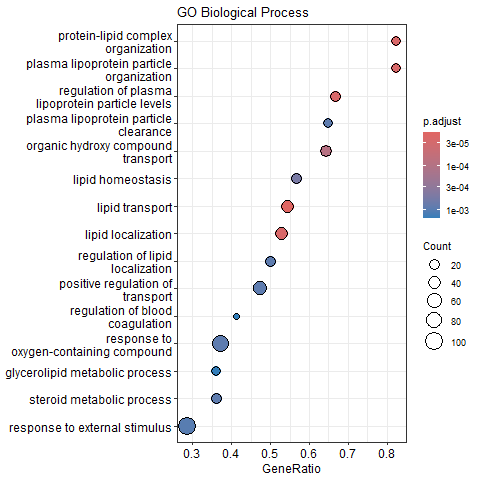

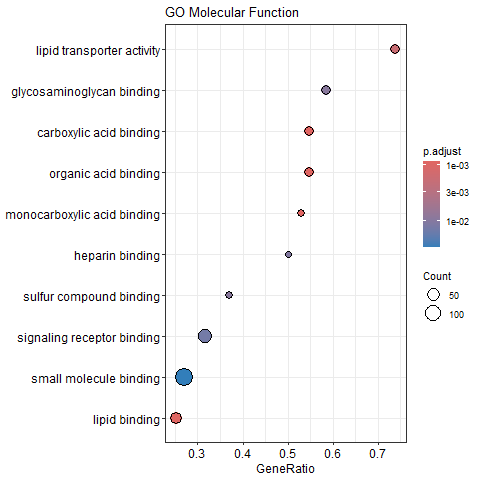

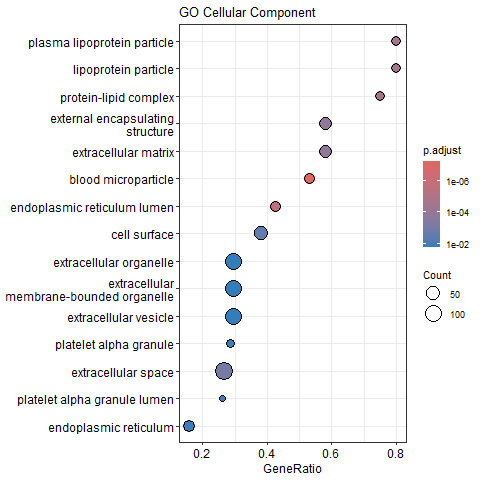

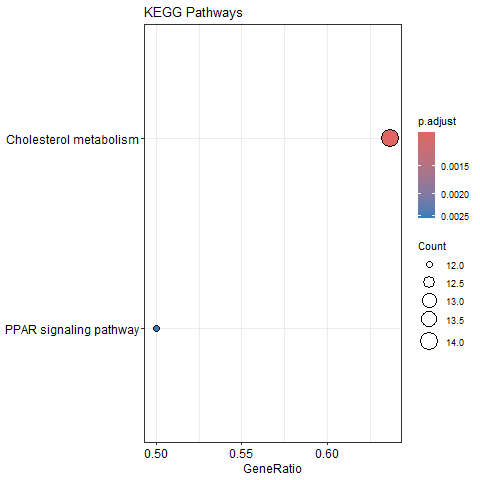

In [9]:
%%R -i FIGURES_DIR
safe_dotplot <- function(obj, title, showCat=15) {
    df <- as.data.frame(obj)
    if (nrow(df) > 0) {
        p <- dotplot(obj, showCategory=min(showCat, nrow(df))) + ggtitle(title)
        ggsave(paste0(FIGURES_DIR, "/gsea_", gsub(" ","_",tolower(title)), ".png"),
               p, width=10, height=7, dpi=200)
        print(p)
    } else {
        cat(sprintf("No results for '%s'\n", title))
    }
}
safe_dotplot(gsea_bp,   "GO Biological Process")
safe_dotplot(gsea_mf,   "GO Molecular Function")
safe_dotplot(gsea_cc,   "GO Cellular Component")
safe_dotplot(gsea_kegg, "KEGG Pathways")


## Filter HCC-relevant pathways

In [10]:
%%R
# Key biological themes from the Wang et al. paper
themes <- list(
    "Lipid metabolism"   = "lipid|fatty.acid|cholesterol|PPAR",
    "Glycolysis / energy"= "glycolysis|gluconeogenesis|glucose|TCA",
    "PI3K-AKT / Wnt"    = "PI3K|AKT|Wnt|beta.catenin|mTOR",
    "Immune regulation"  = "immune|inflamm|cytokine|T cell|B cell|interferon"
)

bp_df <- as.data.frame(gsea_bp)
for (theme in names(themes)) {
    hits <- grep(themes[[theme]], bp_df$Description, ignore.case=TRUE)
    if (length(hits) > 0) {
        cat(sprintf("\n=== %s ===\n", theme))
        print(bp_df[hits, c("Description","NES","p.adjust")][1:min(5,length(hits)),])
    }
}



=== Lipid metabolism ===
                                  Description       NES     p.adjust
GO:0006869                    lipid transport -2.140419 1.675489e-05


GO:0071825 protein-lipid complex organization -2.201717 2.257169e-05
GO:0010876                 lipid localization -2.116587 2.257169e-05
GO:0055088                  lipid homeostasis -2.124033 5.079695e-04
GO:1905952   regulation of lipid localization -2.077918 8.759800e-04

=== Immune regulation ===
                                                     Description       NES
GO:0006954                                 inflammatory response -1.657895
GO:0050727                   regulation of inflammatory response -1.667854
GO:0002526                           acute inflammatory response -1.836598
GO:0006955                                       immune response -1.373900
GO:0071706 tumor necrosis factor superfamily cytokine production -1.688911
              p.adjust
GO:0006954 0.005333595
GO:0050727 0.033082034
GO:0002526 0.033365662
GO:0006955 0.046329605
GO:0071706 0.047768502


## Export GSEA tables

In [11]:
TABLES_DIR = str(TABLES_DIR)

In [12]:
%%R -i TABLES_DIR
write.csv(as.data.frame(gsea_bp),   paste0(TABLES_DIR,"/gsea_go_bp.csv"),   row.names=FALSE)
write.csv(as.data.frame(gsea_mf),   paste0(TABLES_DIR,"/gsea_go_mf.csv"),   row.names=FALSE)
write.csv(as.data.frame(gsea_cc),   paste0(TABLES_DIR,"/gsea_go_cc.csv"),   row.names=FALSE)
write.csv(as.data.frame(gsea_kegg), paste0(TABLES_DIR,"/gsea_kegg.csv"),    row.names=FALSE)
cat("GSEA tables saved to results/tables/\n")


GSEA tables saved to results/tables/
